# **Car Price Analysis**

## Objectives




## Inputs

Data set content: For this project the data source Kaggle and there are just 205 cars.  The dataset tells us details about the car, from its size, engine specification, fuel, power, aspiration (turbo) efficiency and price. Limitations is we’re not told where in the US its sold, nor by who.  We can assume they’re all new cars without mileage and randomly sourced from various states around the US.   This potentially limits the reliability of the conclusions for example location bias due to climate or state wealth.


## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 


## Additional Comments

Business requirements and goals: They want to finds positive coefficients in any of the data they’ve obtained to tell them which features of cars American buyers are willing to pay more for.  So, aim is to identify which features are worth investing in for their export market and to design vehicles that match American preferences to boost sales.


## What you are looking for?

 Questions. Which answer is using Analytics to support Making an evidence based business decision.

 ## Project Plan ##
 
 What is the plan to reach the business requirements and answer the questions?

---

In [10]:
import numpy as np
import pandas as pd

In [11]:
##New code
##this code loads the csv directly from data sets added to Kaggle.
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "CarPrice_Assignment.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "hellbuoy/car-price-prediction",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



## Understanding the data
Explore, get familiar with the structure. Take steps to clean. Follow basic cleaning steps as planned.
Data loss or data inconsistancy can be misleading if the scale of the data is small. Error can change a result. As the set it small its worth doing.

In [12]:
print("First 5 records:", df.head()) #first look at data.
#df.shape # 205 rows with 26
#df.info() ##checking for size, nulls and types.  No issues.  No null values.  Move on.
#df.nunique() # no duplicates
 #Observation: The carname field isn't too useful. The model would be useful to group by if it was seperated cleanly.  Some data living in the name need checking against other fields.
 #lets start cleaning up the dataset taking a copy just in case.
data_cleaned = df.copy() 
duplicate_count = data_cleaned.duplicated().sum()# No duplicate to sort out
missing_data = data_cleaned.isnull().sum() # no null
# No changes.
# At least Convert all fields to lowercase to tidy up the fields.
df.columns = df.columns.str.lower()
df.columns



First 5 records:    car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  p

Index(['car_id', 'symboling', 'carname', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [13]:
df["carname"]
# Splits into a list per row, then extracts index 0 as a string for the car's Make to its own field.
df["make"] = df["carname"].str.split(' ').str[0]
df["make"]
# Displays an array of all distinct make values
print(df["make"].unique())
## wrong models. vw>volswagen

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'nissan'
 'peugeot' 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru'
 'toyota' 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']


In [14]:
# Create the dictionary of error I found.
make_replacements = {
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'toyouta': 'toyota',
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'Nissan': 'nissan',          
    'alfa-romero': 'alfa-romeo'    
}

df['make'] = df['make'].replace(make_replacements)
#Standardising non-capitalisation in the whole set.
df['make'] = df['make'].str.lower()
df
#observer whole dataset to spot things in car name we still can use before we drop the column.
#(Auto)- reference to transmission which we don't have.      (diesel) - reference to fueltype which needs looking at to confirm.
#(turbo) - reference to aspiration which we need to confirm,
# Takes time. using AI to help find what wlse is hidden in carname. Copy and paste all column and carname field to gemini.

,car_id,symboling,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,make
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [15]:
# 1. Fix 'fueltype'
# Check if carname mentions 'diesel' and current fueltype is not already 'diesel'
diesel_mask = df['carname'].str.contains('diesel', case=False, na=False)
df.loc[diesel_mask & (df['fueltype'] != 'diesel'), 'fueltype'] = 'diesel'

# 2. Fix 'aspiration'
# Check if carname mentions 'turbo' and current aspiration is not already 'turbo'
turbo_mask = df['carname'].str.contains('turbo', case=False, na=False)
df.loc[turbo_mask & (df['aspiration'] != 'turbo'), 'aspiration'] = 'turbo'

# 3. Fix 'carbody'
# Mapping parenthetical wagon flags like '(sw)' to 'wagon' only if not already set
wagon_mask = df['carname'].str.contains(r'\(sw\)', case=False, na=False)
df.loc[wagon_mask & (df['carbody'] != 'wagon'), 'carbody'] = 'wagon'



##Rejected AI suggestions.
## Mapping coupe indicators like 'coupe' in carname
#coupe_mask = df['carname'].str.contains('coupe', case=False, na=False)
#df.loc[coupe_mask & (df['carbody'] != 'coupe'), 'carbody'] = 'coupe'
#After review Take a look at the row buick regal sport coupe (turbo). 
# In automotive terms, manufacturers often sold trim levels called "Sport Coupe" on 2-door
#  hardtops or hatchbacks, while the database schema might classify the official body style as a 
#  hatchback or hardtop. Forcing carbody to 'coupe' based solely on a marketing trim name in 
#  carname overwrites the original, more precise carbody classification.
# 4. Extract and create 'transmission' column (New Field)
##These change suggestion were skipped.
# 1. Deterministic Extraction (High Confidence)
# These are exact parenthetical patterns where we are 
# 100% sure what the text means:(sw) $\rightarrow$ carbody = 'wagon'(auto) $\rightarrow$ transmission = 'automatic'(turbo) $\rightarrow$ aspiration = 'turbo'(diesel) $\rightarrow$ fueltype = 'diesel'

In [16]:
#check for invalid text based field ising value_counts() function.
for field in df[["fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "enginetype"]]:
    print(df[field].value_counts(), end='\n|\n')

#Some are rare but all valid entries. Rare types can be grouped together as 'rare' to reduce noise.    

fueltype
gas       183
diesel     22
Name: count, dtype: int64
|
aspiration
std      167
turbo     38
Name: count, dtype: int64
|
doornumber
four    115
two      90
Name: count, dtype: int64
|
carbody
sedan          91
hatchback      68
wagon          32
hardtop         8
convertible     6
Name: count, dtype: int64
|
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
|
enginelocation
front    202
rear       3
Name: count, dtype: int64
|
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64
|


In [17]:
for col in df.columns.to_list():
  print(f"{col} \n{df[col].value_counts(normalize=True)} \n\n")

#nobody cares about the hardtop or the convertable because the frequency is rare, so rather than keep those name ratteling about we replace them.

car_id 
car_id
1      0.004878
2      0.004878
3      0.004878
4      0.004878
5      0.004878
         ...   
201    0.004878
202    0.004878
203    0.004878
204    0.004878
205    0.004878
Name: proportion, Length: 205, dtype: float64 


symboling 
symboling
 0    0.326829
 1    0.263415
 2    0.156098
 3    0.131707
-1    0.107317
-2    0.014634
Name: proportion, dtype: float64 


carname 
carname
peugeot 504                 0.029268
toyota corolla              0.029268
toyota corona               0.029268
subaru dl                   0.019512
mitsubishi outlander        0.014634
                              ...   
volkswagen super beetle     0.004878
volkswagen rabbit custom    0.004878
volvo 245                   0.004878
volvo diesel                0.004878
volvo 246                   0.004878
Name: proportion, Length: 147, dtype: float64 


fueltype 
fueltype
gas       0.892683
diesel    0.107317
Name: proportion, dtype: float64 


aspiration 
aspiration
std      0.814634
turbo 

In [18]:
##tidy up the date a bit
## using pipline transform the fuel type, turbo and number of doors automatically into new true or false column.
from feature_engine.encoding import OneHotEncoder
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
      ('ohe', OneHotEncoder(variables=['fueltype', 'aspiration','doornumber','enginelocation']) )
])


df = pipeline.fit_transform(df)

# we can replace cylinders number as string with integers for better comparison.
# Define the translation rule from text to integer
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

# Map the string column to integers in a new 'cylinders' field
df['cylinders'] = df['cylindernumber'].map(cylinder_map)

#finally for things that are a bit rare and won't affect the data set by what they actually are we can just class as Rare
#this pipeline RareLabel does the heavy lifting for us.      Sourced from ML feature topic 3 of LMS.
from feature_engine.encoding import RareLabelEncoder

pipeline = Pipeline([
      ('rle_carbody', RareLabelEncoder(tol=0.1,
                                     n_categories=2,
                                     variables=['carbody']) ), 
      ('rle_fuelsystem', RareLabelEncoder(tol=0.08,
                                     n_categories=2,
                                     variables=['fuelsystem']) )
])

df = pipeline.fit_transform(df)

df = df.drop(columns=['carname', 'cylindernumber'])
df


,car_id,symboling,carbody,drivewheel,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,...,make,fueltype_gas,fueltype_diesel,aspiration_std,aspiration_turbo,doornumber_two,doornumber_four,enginelocation_front,enginelocation_rear,cylinders
0,1,3,Rare,rwd,88.6,168.8,64.1,48.8,2548,dohc,...,alfa-romeo,1,0,1,0,1,0,1,0,4
1,2,3,Rare,rwd,88.6,168.8,64.1,48.8,2548,dohc,...,alfa-romeo,1,0,1,0,1,0,1,0,4
2,3,1,hatchback,rwd,94.5,171.2,65.5,52.4,2823,ohcv,...,alfa-romeo,1,0,1,0,1,0,1,0,6
3,4,2,sedan,fwd,99.8,176.6,66.2,54.3,2337,ohc,...,audi,1,0,1,0,0,1,1,0,4
4,5,2,sedan,4wd,99.4,176.6,66.4,54.3,2824,ohc,...,audi,1,0,1,0,0,1,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,wagon,rwd,109.1,188.8,68.9,55.5,2952,ohc,...,volvo,1,0,1,0,0,1,1,0,4
201,202,-1,sedan,rwd,109.1,188.8,68.8,55.5,3049,ohc,...,volvo,1,0,0,1,0,1,1,0,4
202,203,-1,sedan,rwd,109.1,188.8,68.9,55.5,3012,ohcv,...,volvo,1,0,1,0,0,1,1,0,6
203,204,-1,sedan,rwd,109.1,188.8,68.9,55.5,3217,ohc,...,volvo,0,1,0,1,0,1,1,0,6


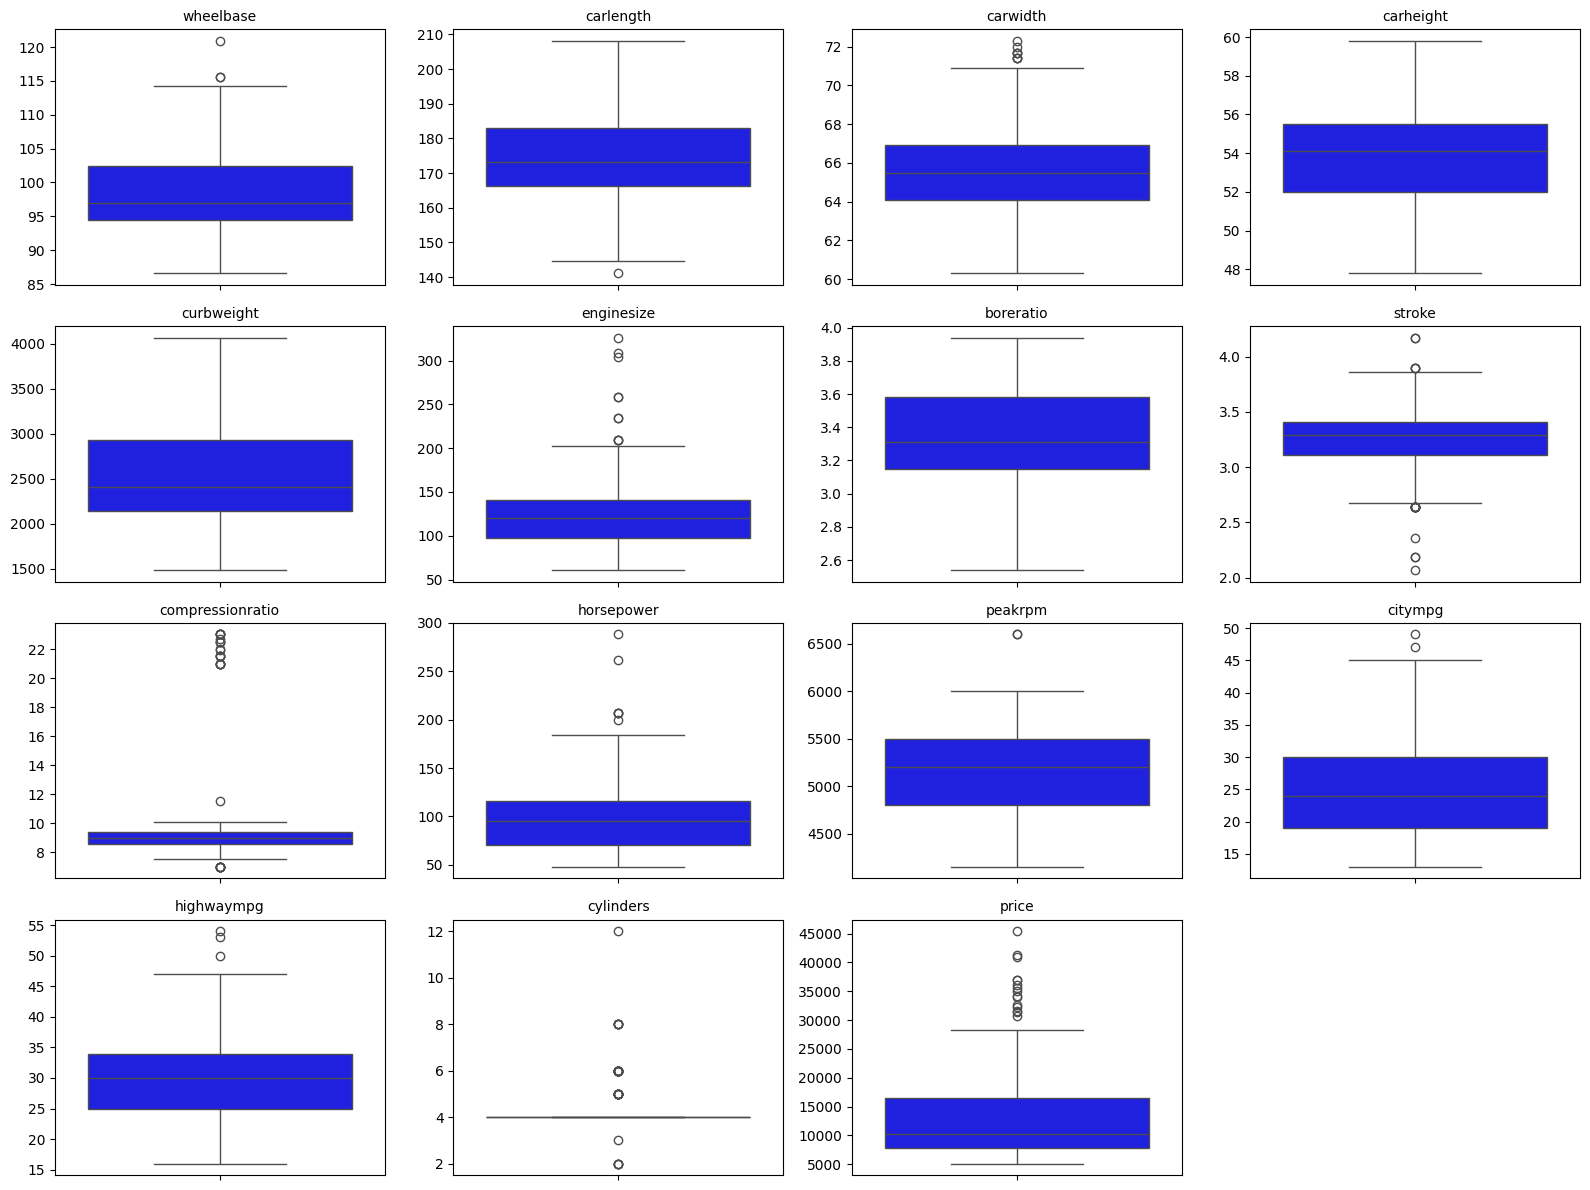

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of continuous columns to inspect numbers in the data.
num_cols = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 
    'curbweight', 'enginesize', 'boreratio', 'stroke', 
    'compressionratio', 'horsepower', 'peakrpm', 'citympg', 
    'highwaympg', 'cylinders', 'price'
]

# 2. Create a figure with a 4x4 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))

# 3. Flatten the 2D array of axes so we can loop through it easily
axes = axes.flatten()

# 4. Loop through each column and draw its boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='blue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

# 5. Hide any unused subplots (since 14 plots leave 2 empty slots in a 4x4 grid)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

# 6. Adjust layout so titles and labels do not overlap
plt.tight_layout()
plt.show()

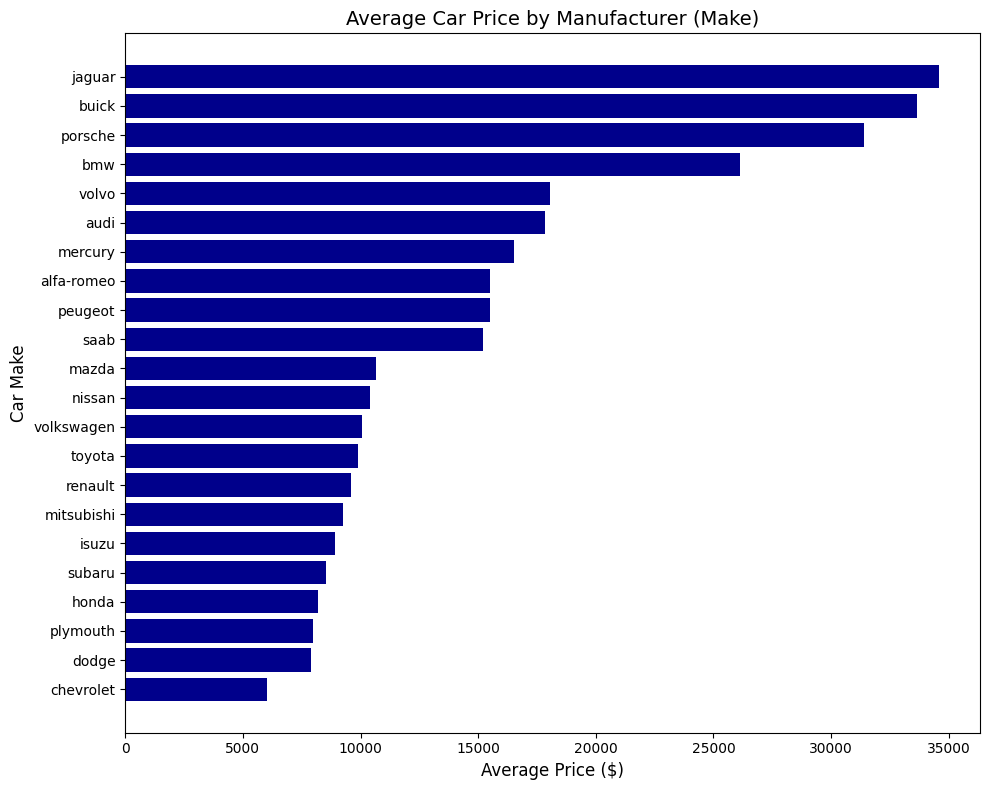

In [76]:
import matplotlib.pyplot as plt
# Group by 'make' and calculate average price for each brand
avg_price_by_make = df.groupby('make')['price'].mean().sort_values(ascending=False)
# 1. Create a clean figure canvas
plt.figure(figsize=(10, 8))

# 2. Draw horizontal bar chart (sorted from highest to lowest price)
plt.barh(avg_price_by_make.index, avg_price_by_make.values, color='darkblue')

# 3. Add labels and title
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Car Make', fontsize=12)
plt.title('Average Car Price by Manufacturer (Make)', fontsize=14)

# 4. Invert y-axis so the most expensive car brand appears at the very top
plt.gca().invert_yaxis()

# 5. Render plot cleanly
plt.tight_layout()
plt.show()

The make of luxary cars can affect the price and the result so can engine size, those are high priced high because their engines are massive. (A general assumtion being made from knowledge of car)

In [93]:
# I had the idea it might be good to look at the factors in the top 20 % and bottom 20 % which we obviously present or lacking.
# then pick the most highly occuring as the factors brining the price up or down.
# 1. Dynamically calculate the 20th and 80th percentile prices
low_cutoff = df['price'].quantile(0.20)
high_cutoff = df['price'].quantile(0.80)

print(f"Bottom 20% threshold: ${low_cutoff:,.2f}")
print(f"Top 20% threshold: ${high_cutoff:,.2f}")

# 2. Build your boolean masks using the dynamic thresholds
low_price_mask = df['price'] < low_cutoff
high_price_mask = df['price'] > high_cutoff

Bottom 20% threshold: $7,385.80
Top 20% threshold: $17,493.80


In [ ]:

# Add a label column to identify price tier
df_low = df[df['price'] <= low_cutoff].copy()
df_low['price_group'] = 'Low Price (Bottom 20%)'

df_high = df[df['price'] >= high_cutoff].copy()
df_high['price_group'] = 'High Price (Top 20%)'

# Combine both sets into one DataFrame for plotting
df_quartiles = pd.concat([df_low, df_high])


# All possible numerical fields to compare
#num_fields = ['horsepower', 'enginesize', 'carwidth', 'curbweight', 'wheelbase', 'citympg']]
num_fields = ['symboling','carbody','drivewheel','wheelbase','carlength','carwidth','carheight','curbweight','enginetype','enginesize','fuelsystem','boreratio','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg','make','fueltype_gas','fueltype_diesel','aspiration_std','aspiration_turbo','doornumber_two','doornumber_four','enginelocation_front','enginelocation_rear','cylinders','market_segment']
              


# 3. Create a 2x3 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, field in enumerate(num_fields):
    sns.boxplot(
        data=df_quartiles,
        x='price_group',
        y=field,
        palette={'Low Price (Bottom 20%)': 'mediumseagreen', 'High Price (Top 20%)': 'crimson'},
        ax=axes[i]
    )
    axes[i].set_title(f'{field.title()} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(field.title(), fontsize=10)

plt.suptitle('Comparing Low Price vs. High Price Vehicle Characteristics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()              


KeyError: ('symboling', 'carbody', 'drivewheel', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'make', 'fueltype_gas', 'fueltype_diesel', 'aspiration_std', 'aspiration_turbo', 'doornumber_two', 'doornumber_four', 'enginelocation_front', 'enginelocation_rear', 'cylinders', 'market_segment')

In [ ]:
# Filter high/low priced cars top 20.

high_price_mask = df['price'] > high_cutoff
low_price_mask = df['price'] < low_cutoff
# Select expected key performance columns alongside make and price
high_spec_comparison = df.loc[high_price_mask, ['make', 'enginesize', 'horsepower', 'cylinders', 'price',  'enginetype']]
low_spec_comparison = df.loc[low_price_mask, ['make', 'enginesize', 'horsepower', 'cylinders', 'price',  'enginetype']]

# Sort by price descending to inspect the correlation
#print(high_spec_comparison .sort_values(by='price', ascending=False))
print(low_spec_comparison.sort_values(by='price', ascending=True))
#The inspected data looks okay. These are priced high because their engines are massive.
#high_spec_comparison.count()
 


Looking at the high end of the cars in the set and with my knowledge of cars I'm going to focus straight away on the areas in those high priced cars that may contribute to their price.
Engine size, engine type, cylinders,  horsepower, carlength

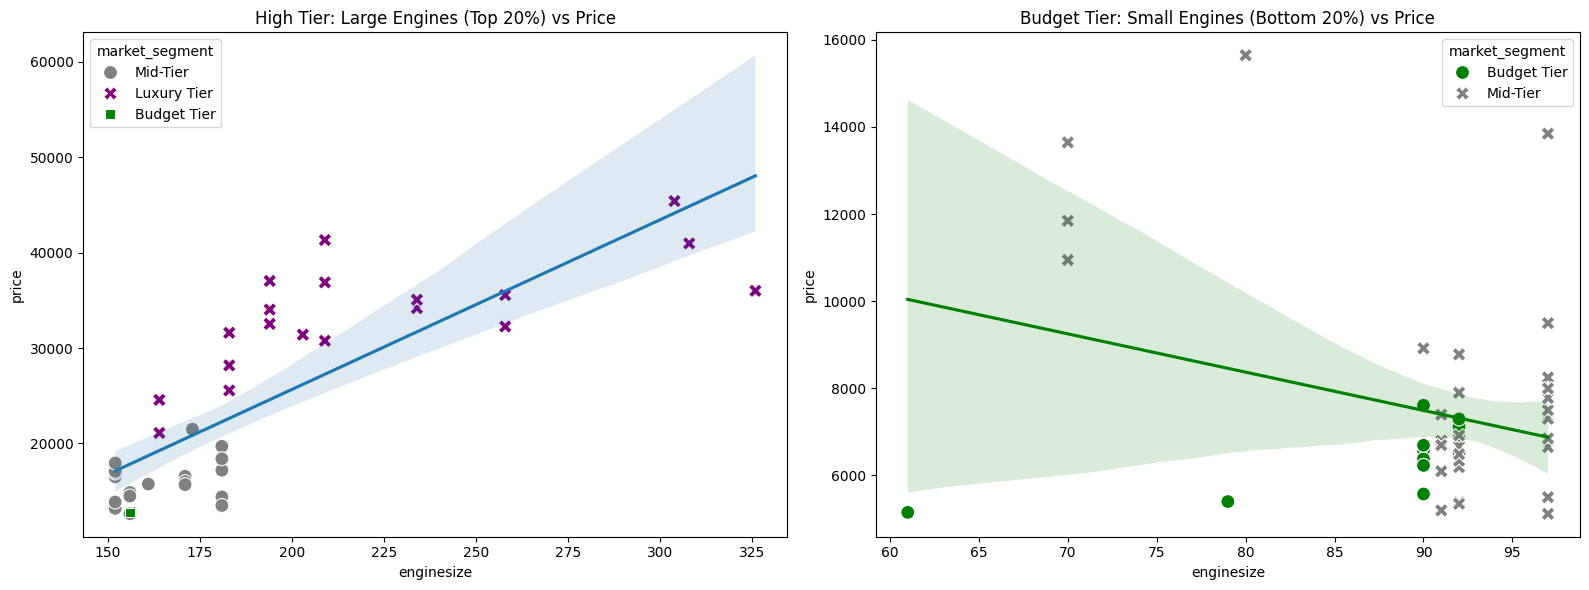

In [74]:
# 1. Prepare dynamic high/low flags and engine thresholds
high_engine_cutoff = df['enginesize'].quantile(0.80)
low_engine_cutoff = df['enginesize'].quantile(0.20)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define manufacturer brand lists well known top and low priced from chart.
luxury_makes = ['porsche', 'jaguar', 'bmw', 'buick']
budget_makes = ['honda', 'dodge', 'plymouth', 'chevrolet']

# 2. Create a clean category column based on brand lists
def assign_market_segment(make_name):
    if make_name in luxury_makes:
        return 'Luxury Tier'
    elif make_name in budget_makes:
        return 'Budget Tier'
    else:
        return 'Mid-Tier'

#Use the function above to assign the market segment we might see.
df['market_segment'] = df['make'].apply(assign_market_segment)

# 3. Calculate dynamic engine size thresholds using quantiles
high_engine_cutoff = df['enginesize'].quantile(0.80)
low_engine_cutoff = df['enginesize'].quantile(0.20)

# 4. Create canvas for 2 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------------------------
# CHART 1: High-Tier / Luxury Focus (Large Engines)
# ----------------------------------------------------
high_df = df[df['enginesize'] >= high_engine_cutoff].copy()

sns.scatterplot(
    data=high_df,
    x='enginesize',
    y='price',
    hue='market_segment',
    style='market_segment',
    palette={'Luxury Tier': 'purple', 'Mid-Tier': 'gray', 'Budget Tier': 'green'},
    s=100,
    ax=axes[0]
)
# Add regression line to show general trend direction
sns.regplot(data=high_df, x='enginesize', y='price', scatter=False, ax=axes[0])
axes[0].set_title('High Tier: Large Engines (Top 20%) vs Price', fontsize=12)

# ----------------------------------------------------
# CHART 2: Budget Focus (Small Engines)
# ----------------------------------------------------
low_df = df[df['enginesize'] <= low_engine_cutoff].copy()

sns.scatterplot(
    data=low_df,
    x='enginesize',
    y='price',
    hue='market_segment',
    style='market_segment',
    palette={'Luxury Tier': 'purple', 'Mid-Tier': 'gray', 'Budget Tier': 'green'},
    s=100,
    ax=axes[1]
)
sns.regplot(data=low_df, x='enginesize', y='price', scatter=False, ax=axes[1], color='green')
axes[1].set_title('Budget Tier: Small Engines (Bottom 20%) vs Price', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
top_priced_cars =  df.groupby('make')['price'].mean().sort_values(ascending=False)
top_priced_cars

This demonstrates there is some correlation with engine size which is obvious as engines cost a lot so would push up the price.
this alone proves nothing, we should be looking at a number of factors together which are desirable without spending a lot on huge engines.



In [ ]:
price_scores = df.corr(numeric_only=True)['price']


positive_scores = price_scores[price_scores > 0].sort_values(ascending=False)
print(positive_scores)


If R (positive) is the correlation is it a measure of how related the value is to price but its not the coefficient of determination (how much can be explained), for that you need to multiple R by itself R^2

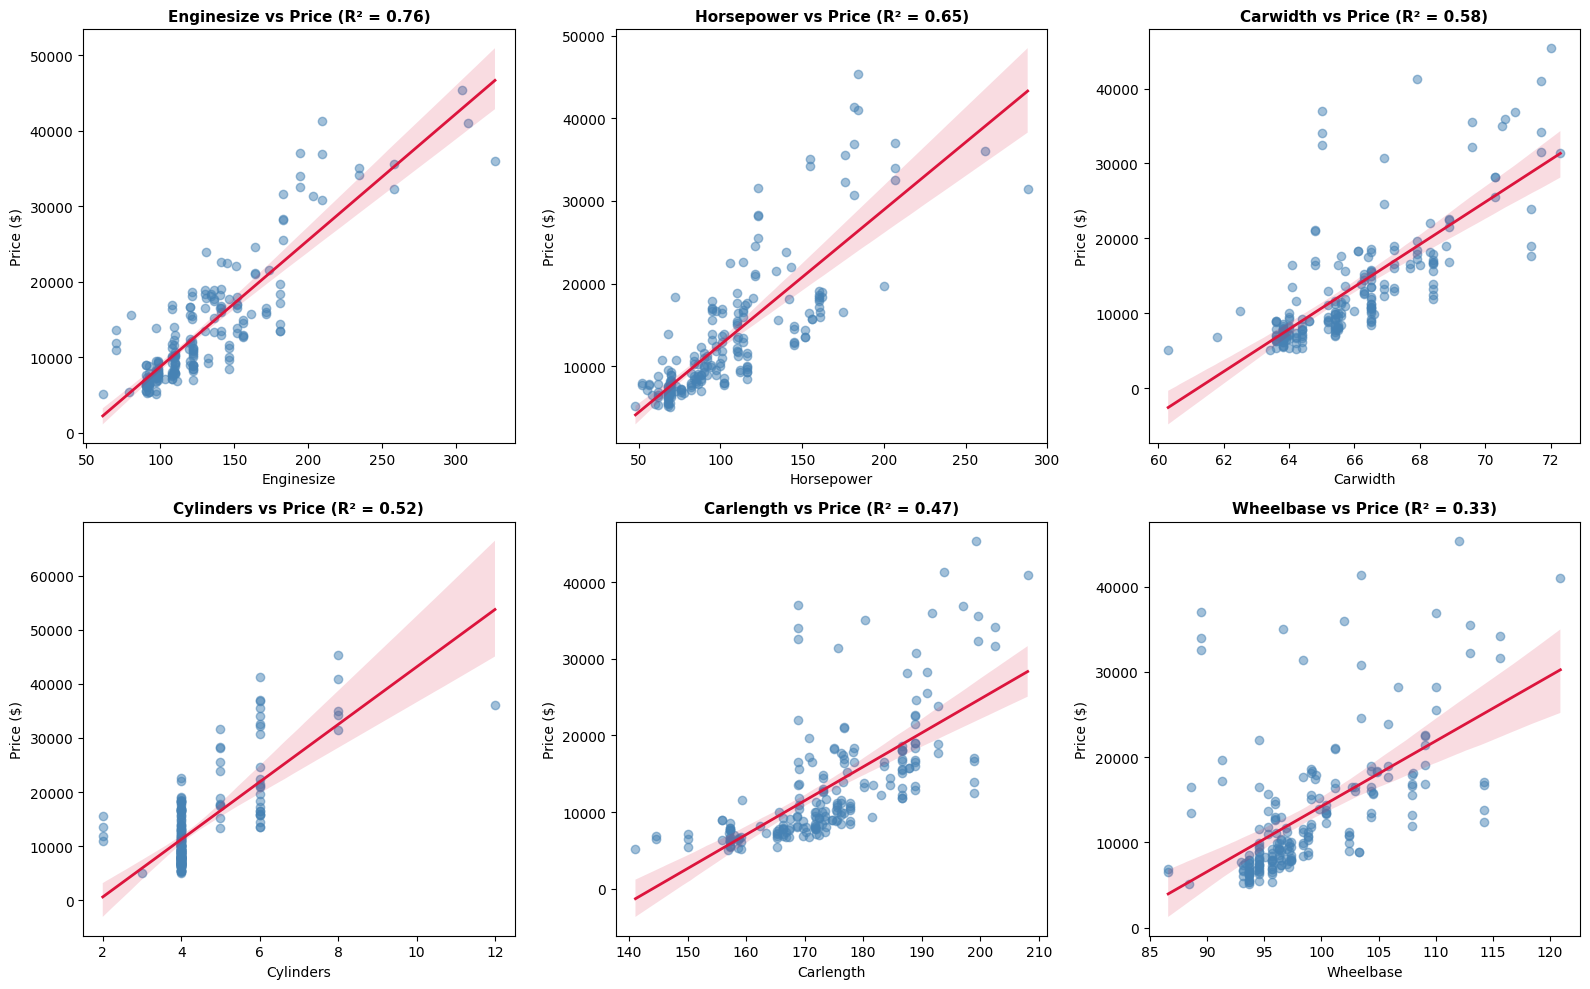

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the 6 selected features
selected_features = [
    'enginesize', 'horsepower', 'carwidth', 
    'cylinders', 'carlength', 'wheelbase'
]

# 2. Create a figure with a 2x3 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# 3. Flatten the 2D grid array into a single 1D list for easy looping
axes = axes.flatten()

# 4. Loop through each feature and create a scatter plot with a trendline
for i, feature in enumerate(selected_features):
    sns.regplot(
        data=df,
        x=feature,
        y='price',
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 'color': 'steelblue'},  # Translucent points to handle overlap
        line_kws={'color': 'crimson', 'linewidth': 2}     # Red trendline highlighting direction
    )
    
    # Calculate R^2 score for title context
    r_val = df[feature].corr(df['price'])
    r2_val = r_val ** 2
    
    axes[i].set_title(f"{feature.title()} vs Price (R² = {r2_val:.2f})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature.title(), fontsize=10)
    axes[i].set_ylabel("Price ($)", fontsize=10)

# 5. Adjust spacing so titles and axis labels do not overlap
plt.tight_layout()
plt.show()

For Budget Cars: High MPG is a huge selling point. Buyers want to save money at the gas pump, so a higher MPG adds value to an economical vehicle.

For High-Performance/Luxury Cars: MPG is completely ignored. Buyers prioritize horsepower and speed, accepting low MPG as a necessary trade-off for a big engine.

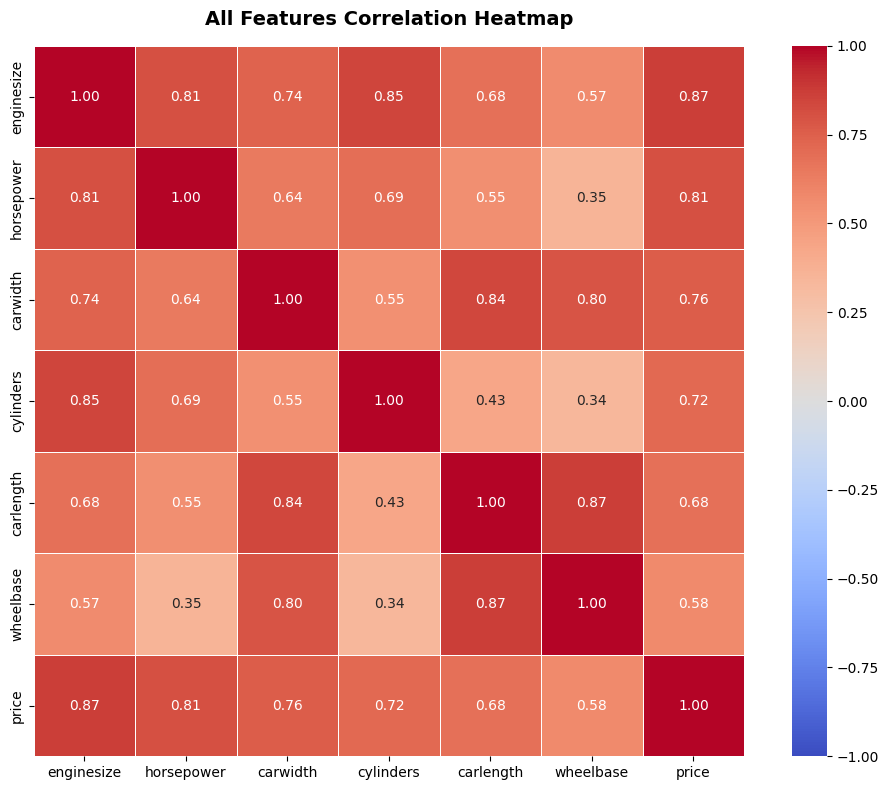

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our finalized list of clean numerical features + target
final_features = [
    'enginesize', 
    'horsepower', 
    'carwidth', 
    'cylinders', 
    'carlength', 
    'wheelbase',
]

# 2. Compute the Pearson correlation matrix for our clean subset
corr_matrix = df[final_features].corr()

# 3. Set up the figure canvas
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show exact numerical scores inside each cell
    fmt='.2f',           # Round scores to 2 decimal places
    cmap='coolwarm',     # Red = Strong Positive, Blue = Strong Negative
    vmin=-1, vmax=1,     # Fix color scale limits between -1.0 and +1.0
    linewidths=0.5,      # Add subtle line dividers between cells
    square=True          # Keep cells as perfect squares
)

plt.title('All Features Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

The curbweight and enginesize, and overall dimensions (carlength, carwidth, wheelbase) often move together. In statistics, when features are strongly correlated with each other, we call it Multicollinearity.
To make better use of the heat map to read off features that are good Correlation Scores to price we need to ignore obviously related things.

Multicollinearity: When two or more features measure almost the same underlying physical property (like length, width, and weight), including all of them in a model distorts their true individual effect on price.

To fix this, we can design a weighted scoring system that rewards a feature for having a high correlation with the target (price) while penalising it for being redundant (too similar to other features already selected).



Here is why this specific 3-feature combination forms the strongest, leanest feature set for a price prediction model:1. Engine Performance Signal (enginesize & horsepower)The Argument: Both enginesize ($r = 0.87$) and horsepower ($r = 0.81$) carry the strongest direct relationships with price across the entire dataset.Why keep both? While they correlate with each other, enginesize captures physical motor displacement, while horsepower captures actual tuning and output efficiency. Together, they represent the single most dominant price driver in the automotive market.2. Vehicle Scale Signal (carwidth)The Argument: Among all physical dimension features (carlength, carwidth, wheelbase), carwidth scored the highest raw correlation with price ($r = 0.769$).Why drop the rest? carlength ($r = 0.68$) and wheelbase ($r = 0.58$) suffered massive redundancy penalties because they overlap heavily with carwidth (average redundancy $>0.76$). Keeping carwidth alone captures overall vehicle size and luxury "stance" without cluttering the model with redundant dimensions.3. Dropping cylindersThe Argument: cylinders carries a much lower unweighted score ($r = 0.56$) and provides diminishing returns because engine displacement and power are already captured more precisely by enginesize and horsepower.

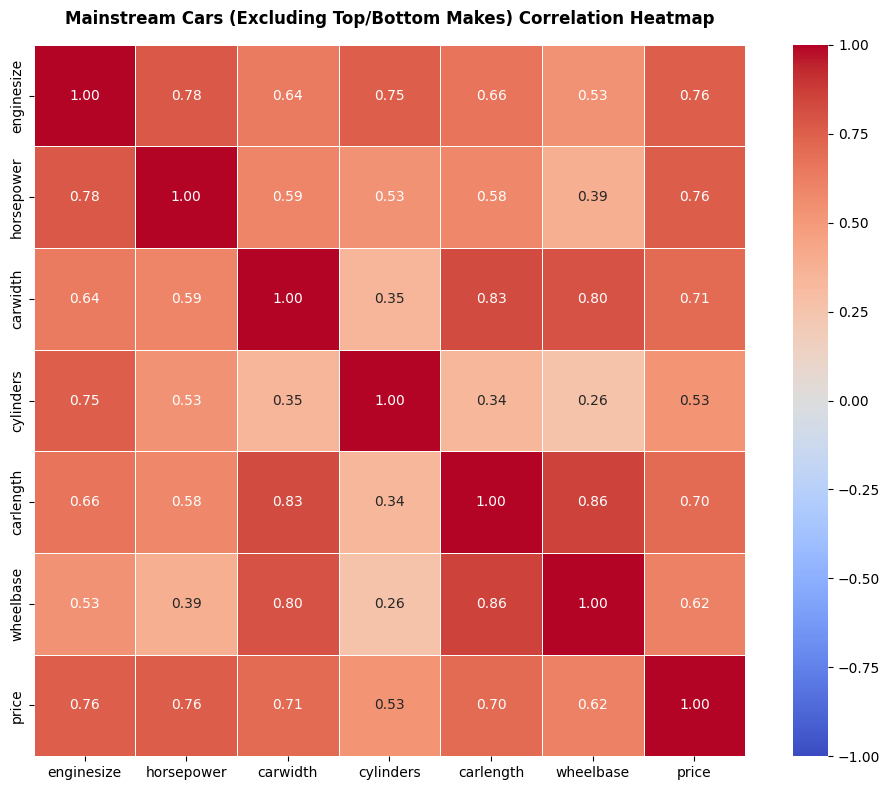

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Define list of clean numerical features AND target
features_with_target = [
    'enginesize', 
    'horsepower', 
    'carwidth', 
    'cylinders', 
    'carlength', 
    'wheelbase',
    'price'
]

# 2. Exclude top 3 and bottom 3 makes
excluded_makes = ['jaguar', 'buick', 'porsche', 'chevrolet', 'dodge', 'plymouth']
df_filtered = df[~df['make'].isin(excluded_makes)]

# 3. Compute Pearson correlation matrix on filtered data
corr_matrix = df_filtered[features_with_target].corr()

# 4. Create a mask to hide the self-correlation diagonal (1.00 values)
#mask = np.eye(len(corr_matrix), dtype=bool)

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
               # Hides the redundant 1.00 diagonal line
    annot=True,          # Show exact numerical scores inside each cell
    fmt='.2f',           # Round scores to 2 decimal places
    cmap='coolwarm',     # Red = Strong Positive, Blue = Strong Negative
    vmin=-1, vmax=1,     # Fix color scale limits
    linewidths=0.5,      # Line dividers
    square=True          # Square cells
)

plt.title('Mainstream Cars (Excluding Top/Bottom Makes) Correlation Heatmap', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()